<a href="https://colab.research.google.com/github/Madathanapalleleena/DL_exploration/blob/main/autocoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3072 - val_loss: 0.2655
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2645 - val_loss: 0.2633
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2581 - val_loss: 0.2505
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2421 - val_loss: 0.2311
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2215 - val_loss: 0.2116
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2056 - val_loss: 0.1983
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1939 - val_loss: 0.1877
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1841 - val_loss: 0.1787
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1758 - val_loss: 0.1711
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1688 - val_loss: 0.1647
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


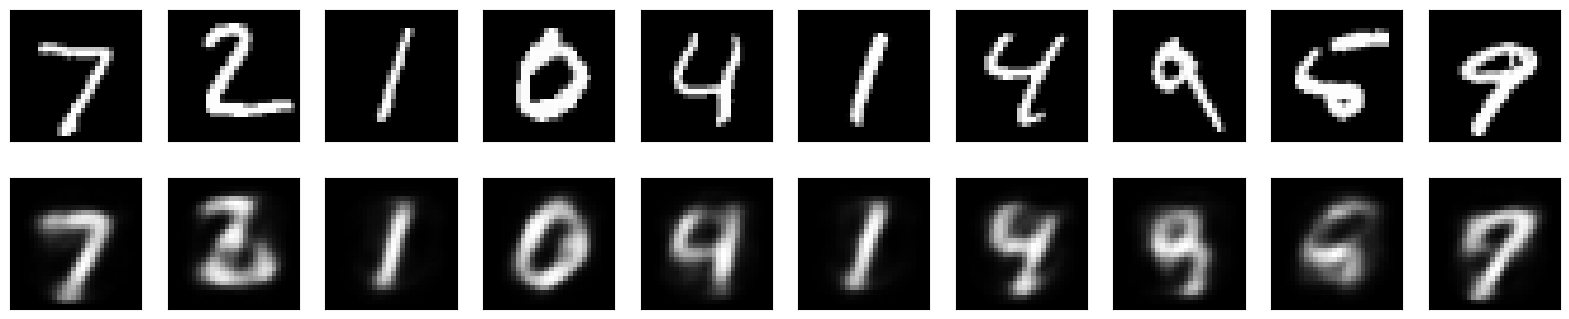

Mean Squared Error (MSE) on test set: 0.03252
Approximate pixel-level accuracy: 73.90%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 62  # 62 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.2438 - val_loss: 0.1612
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1434 - val_loss: 0.1275
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1188 - val_loss: 0.1090
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1042 - val_loss: 0.0978
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0946 - val_loss: 0.0900
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0882 - val_loss: 0.0846
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0838 - val_loss: 0.0813
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0808 - val_loss: 0.0789
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0788 - val_loss: 0.0773
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0775 - val_loss: 0.0762
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0765 - val_loss: 0.0754
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

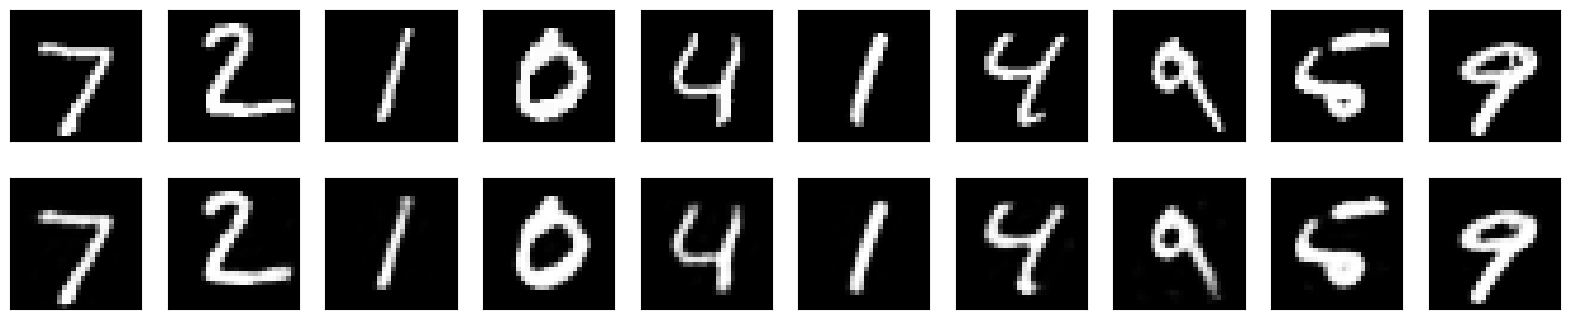

Mean Squared Error (MSE) on test set: 0.00389
Approximate pixel-level accuracy: 93.98%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 64 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

**Hidden layers → ReLU**

**Output layer → Sigmoid**


ReLU works better than Sigmoid in hidden layers because it avoids vanishing gradients, allows faster learning, and captures more detailed features, while Sigmoid compresses values and slows training.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


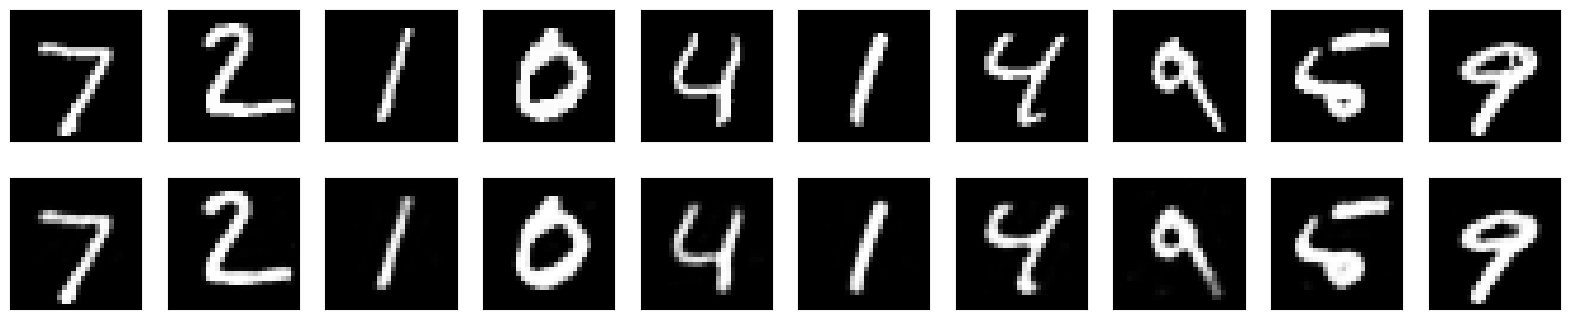

Mean Squared Error (MSE) on test set: 0.00363
Approximate pixel-level accuracy: 94.22%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


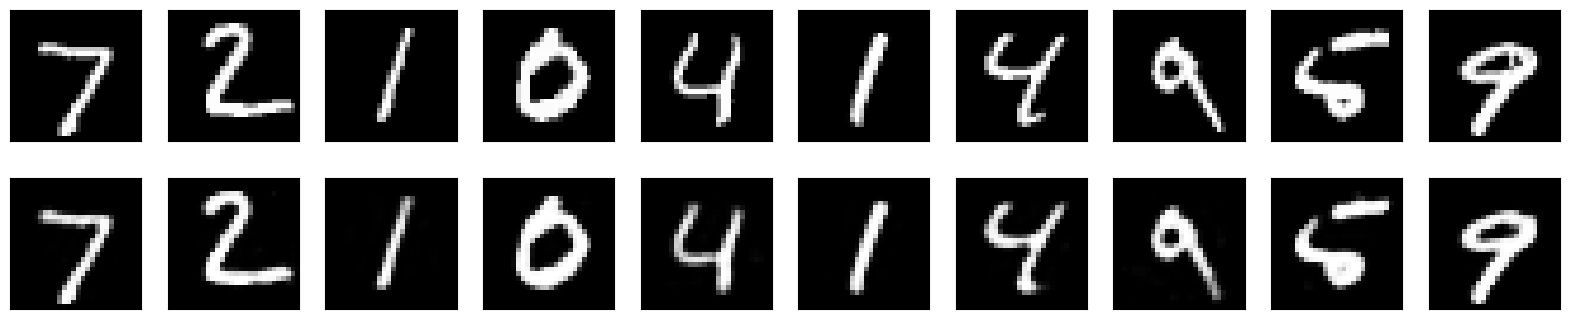

Mean Squared Error (MSE) on test set: 0.00364
Approximate pixel-level accuracy: 94.24%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 64 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, verbose=0,validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.2036 - mse: 0.0471 - val_loss: 0.1381 - val_mse: 0.0251
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1289 - mse: 0.0220 - val_loss: 0.1205 - val_mse: 0.0194
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1174 - mse: 0.0182 - val_loss: 0.1111 - val_mse: 0.0162
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.1089 - mse: 0.0154 - val_loss: 0.1043 - val_mse: 0.0140
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1044 - mse: 0.0139 - val_loss: 0.1021 - val_mse: 0.0133
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1015 - mse: 0.0130 - val_loss: 0.0993 - val_mse: 0.0124
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0993 - mse: 0.0123 - val_loss: 0.0974 - val_mse: 0.0117
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0977 - mse: 0.0118 - val_loss: 0.0962 - val_mse: 0.0113
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms

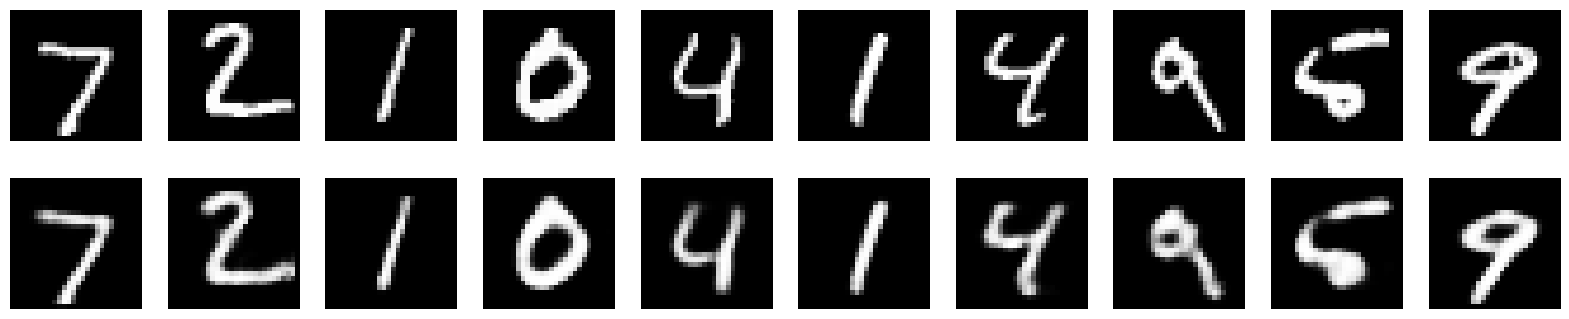

Mean Squared Error (MSE) on test set: 0.00755
Approximate pixel-level accuracy: 91.05%


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Define a Better Autoencoder (More neurons for better reconstruction)
input_layer = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # bottleneck

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

# 3. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])

# 4. Train
history = autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 5. Predict
decoded_imgs = autoencoder.predict(x_test)

# 6. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

# 7. Evaluate (pixel-level similarity)
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: Simple "accuracy" metric
# Count pixels that match closely (difference < 0.1)
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")

# **Conclusions:**


**when the data is --> epochs=20, batch_size=256, shuffle=True**

input_dim = 784  # 28x28 images

encoding_dim = 64  # 64 features - Compressed representation

relu --> in hidden layer

sigmoid --> output layer

**Output:**

Mean Squared Error (MSE) on test set: 0.00389

Approximate pixel-level accuracy: 93.98%


---



**when the data is --> epochs=20, batch_size=256, shuffle=True**

input_dim = 784  # 28x28 images

encoding_dim = 64  # 64 features - Compressed representation

sigmoid --> in hidden layer

sigmoid --> output layer

Mean Squared Error (MSE) on test set: 0.03252

Approximate pixel-level accuracy: 73.90%



---

**when the data is --> epochs=50, batch_size=256, shuffle=True**

input_dim = 784  # 28x28 images

encoding_dim = 64  # 64 features - Compressed representation

relu --> in hidden layer

sigmoid --> output layer

Mean Squared Error (MSE) on test set: 0.00363

Approximate pixel-level accuracy: 94.22%


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_path = "/content/drive/MyDrive/dataset/archive.zip"

In [3]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/archive")

In [4]:
import os

data_path = "/content/archive"
print(os.listdir(data_path))

['Brain (y-n)']


In [5]:
base_path = "/content/archive/Brain (y-n)/Training"

In [6]:
import tensorflow as tf
import keras
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

In [7]:
data_path = "/content/archive/Brain (y-n)/Training"

categories = ["no", "yes"]
img_size = 128

data = []
labels = []

for category in categories:
    path = os.path.join(data_path, category)
    label = categories.index(category)

    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            img_array = cv2.resize(img_array, (img_size, img_size))
            data.append(img_array)
            labels.append(label)
        except:
            pass

data = np.array(data) / 255.0
labels = np.array(labels)

In [8]:
import cv2

img_path = "/content/archive/Brain (y-n)/Training/no/02e7d2ead4cde2cb075b86925f2813_big_gallery.jpeg"
img = cv2.imread(img_path)

print("Original shape:", img.shape)

Original shape: (630, 630, 3)


Reshape is only needed for Dense networks

If you use **CNN layers**, keep the shape (128, 128, 3) because CNNs expect 2D spatial structure

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step


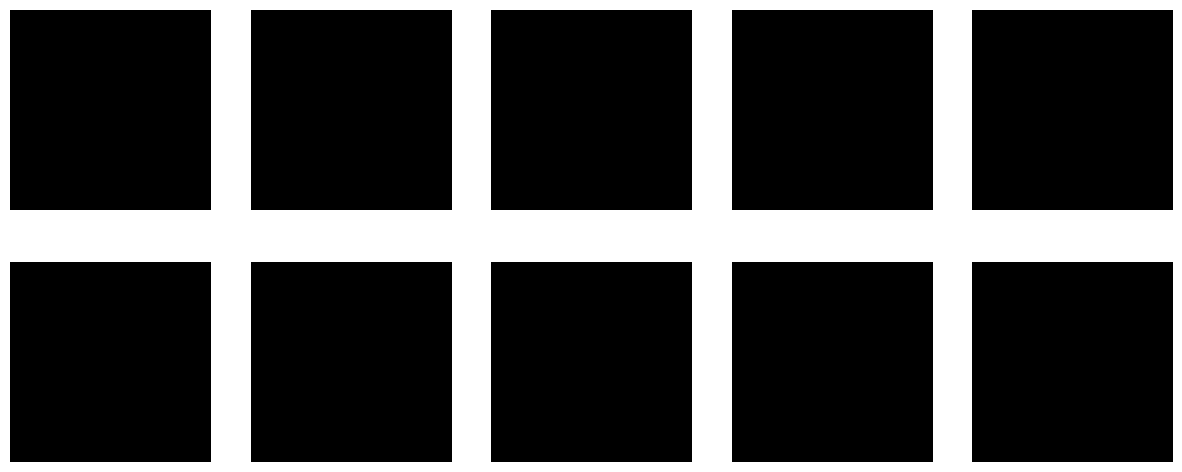

Mean Squared Error (MSE) on test set: 0.00000
Approximate pixel-level accuracy: 100.00%


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
data = np.array(data, dtype='float32') / 255.0
labels = np.array(labels)

# Flatten images for Dense autoencoder
data_flat = data.reshape(len(data), img_size*img_size*3)  # 128x128 RGB -> 49152 features

# Split into train and test sets
x_train, x_test = train_test_split(data_flat, test_size=0.2, random_state=42)

# Define Autoencoder
input_dim = img_size * img_size * 3
encoding_dim = 512  # compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(1024, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(1024, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the Autoencoder silently
autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=32,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=0  # <- suppress epoch printing
)

# Test the Model
decoded_imgs = autoencoder.predict(x_test)

# Visualize some reconstructed images
n = 5
plt.figure(figsize=(15, 6))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(img_size, img_size, 3))
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(img_size, img_size, 3))
    plt.axis('off')
plt.show()

# Evaluate reconstruction
mse = np.mean(np.square(x_test - decoded_imgs))
print(f"Mean Squared Error (MSE) on test set: {mse:.5f}")

# Optional: pixel-level approximate accuracy
accuracy = np.mean(np.abs(x_test - decoded_imgs) < 0.1)
print(f"Approximate pixel-level accuracy: {accuracy*100:.2f}%")